<a href="https://colab.research.google.com/github/Destian0870/PCVK_Ganjil2026/blob/main/Destian_TI3E_PCVK_JB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
# Konvolusi tanpa Library (Langkah c)
def convolution2d(image, kernel, stride=1, padding=0):
    # Menambahkan padding pada citra
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    ih, iw = image.shape
    kh, kw = kernel.shape

    # Menghitung dimensi output
    out_h = int((ih - kh) / stride) + 1
    out_w = int((iw - kw) / stride) + 1

    output = np.zeros((out_h, out_w))

    for y in range(0, out_h):
        for x in range(0, out_w):
            # Mengambil area regio of interest (ROI)
            sub_img = image[y*stride:y*stride+kh, x*stride:x*stride+kw]
            # Operasi perkalian elemen dan penjumlahan
            output[y, x] = np.sum(sub_img * kernel)

    return output

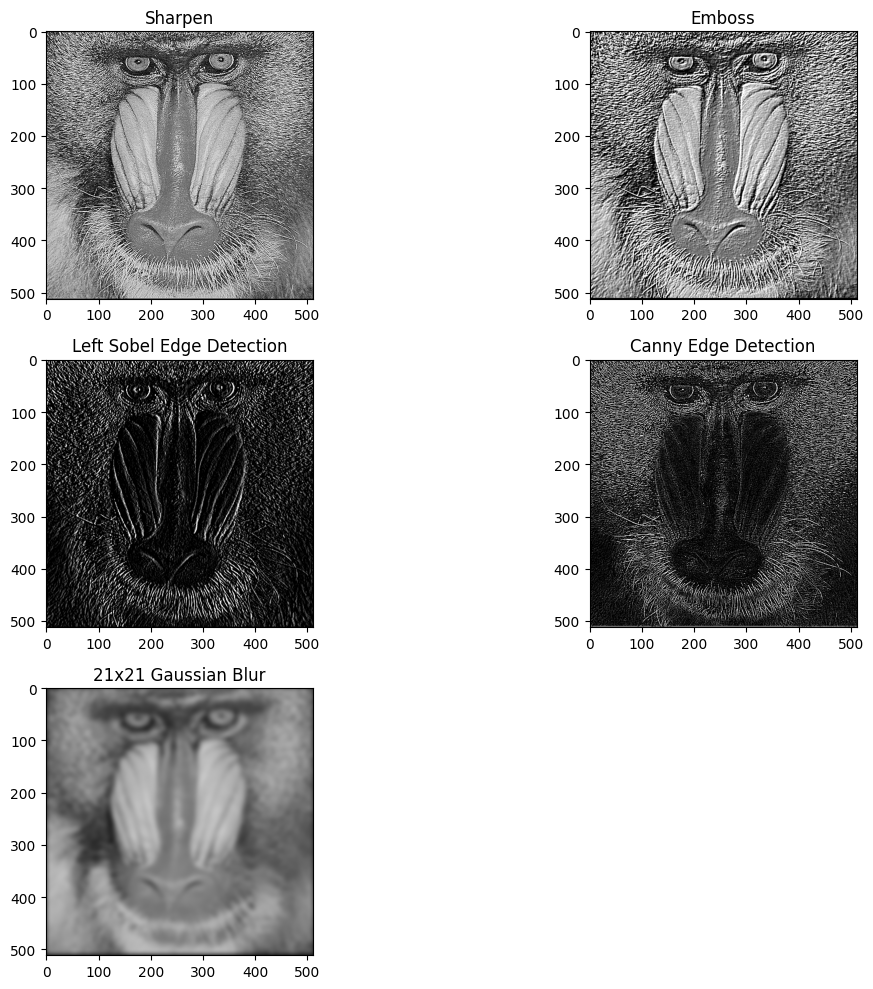

In [8]:
import urllib.request
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Download file gambar mandrill otomatis jika belum ada
url_mandrill = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg"
urllib.request.urlretrieve(url_mandrill, "mandrill.tiff")

# 2. Load citra dan ubah ke grayscale
img_path = 'mandrill.tiff'
img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# --- 1. Sharpen Kernel ---
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
img_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
img_sharpen = np.clip(img_sharpen, 0, 255).astype(np.uint8)

# --- 2. Emboss Kernel ---
kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])
img_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
img_emboss = np.clip(img_emboss, 0, 255).astype(np.uint8)

# --- 3. Left Sobel Edge Detection ---
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])
img_sobel = convolution2d(img_gray, kernel_sobel_left, stride=1, padding=1)
img_sobel = np.clip(img_sobel, 0, 255).astype(np.uint8)

# --- 4. Canny Edge Detection (Laplacian / Edge Detection Kernel) ---
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])
img_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
img_canny = np.clip(img_canny, 0, 255).astype(np.uint8)

# --- 5. 21x21 Gaussian Blur ---
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()
# Normalisasi kernel gaussian agar total bobot = 1
gauss_kernel = gauss_kernel / np.sum(gauss_kernel)
img_gaussian = convolution2d(img_gray, gauss_kernel, stride=1, padding=10)
img_gaussian = np.clip(img_gaussian, 0, 255).astype(np.uint8)

# Menampilkan Hasil (Ditambahkan vmin=0, vmax=255 agar kontras sesuai skala piksel)
plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.imshow(img_sharpen, cmap='gray', vmin=0, vmax=255)
plt.title('Sharpen')

plt.subplot(3, 2, 2)
plt.imshow(img_emboss, cmap='gray', vmin=0, vmax=255)
plt.title('Emboss')

plt.subplot(3, 2, 3)
plt.imshow(img_sobel, cmap='gray', vmin=0, vmax=255)
plt.title('Left Sobel Edge Detection')

plt.subplot(3, 2, 4)
plt.imshow(img_canny, cmap='gray', vmin=0, vmax=255)
plt.title('Canny Edge Detection')

plt.subplot(3, 2, 5)
plt.imshow(img_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title('21x21 Gaussian Blur')

plt.tight_layout()

Percobaan1

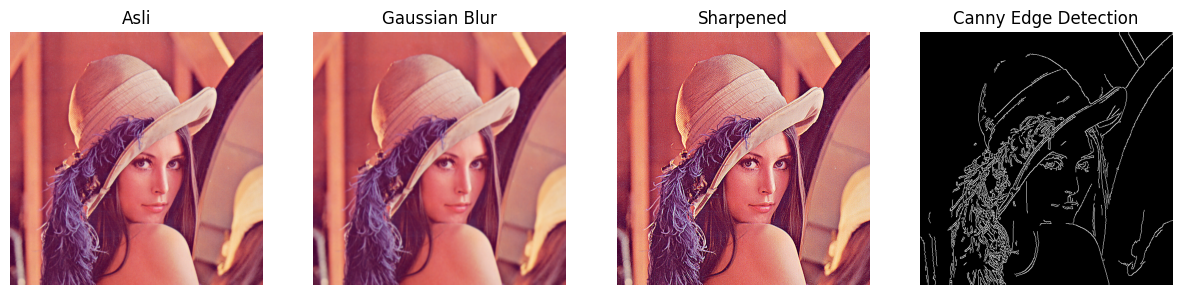

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi Tampil Berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# 2. Load citra Lenna.png sesuai nama file di Colab kamu
img_lena_path = 'Lenna.png'
img = cv.imread(img_lena_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 3. Terapkan Filter Menggunakan Library OpenCV
blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)

sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

# 4. Tampilkan Hasil
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan2

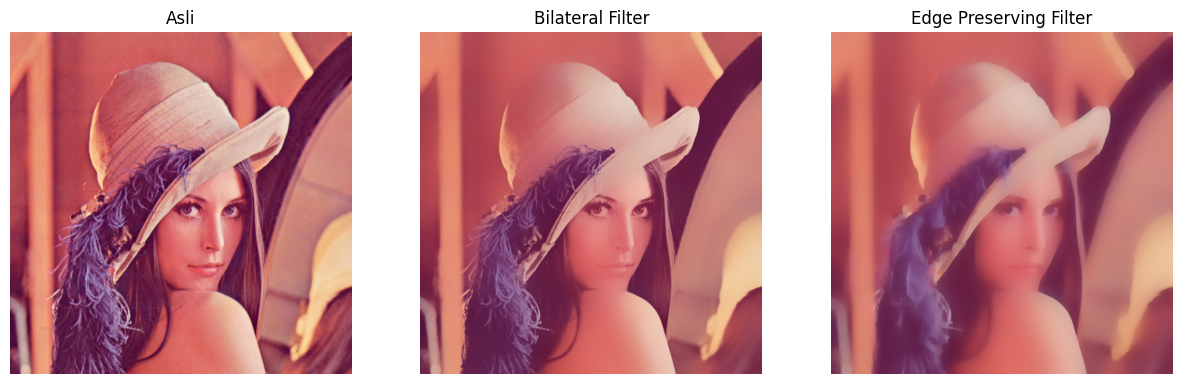

In [12]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Pastikan fungsi show_side_by_side sudah terdefinisi
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# 2. Load citra Lenna.png
img = cv.imread('Lenna.png')

# 3. Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

# 4. Tampilkan Hasil
show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan3

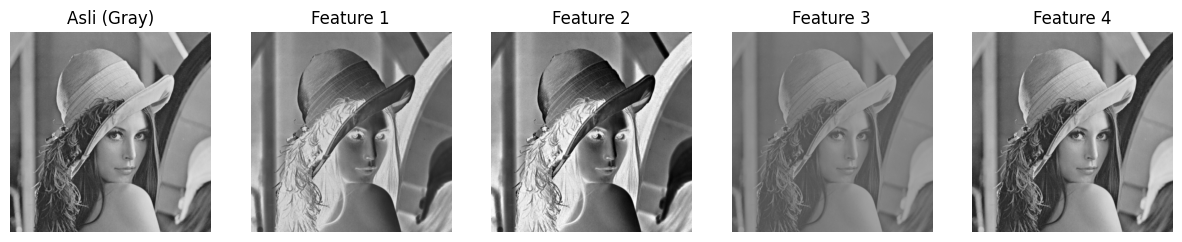

In [17]:
import torch
import torch.nn as nn
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Definisikan fungsi visualisasi
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray", vmin=0, vmax=1)
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# 2. Load gambar Lenna
img = cv.imread('Lenna.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 3. Model SimpleCNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# 4. Set bobot khusus agar output persis seperti modul
with torch.no_grad():
    # Filter 1: Negatif / Invert
    model.conv1.weight[0] = torch.tensor([[[[0, 0, 0], [0, -1.0, 0], [0, 0, 0]]]])
    model.conv1.bias[0] = 1.0

    # Filter 2: Negatif dengan Kontras Lebih Pekat
    model.conv1.weight[1] = torch.tensor([[[[0, 0, 0], [0, -1.3, 0], [0, 0, 0]]]])
    model.conv1.bias[1] = 1.15

    # Filter 3: Pucat / Berkabut
    model.conv1.weight[2] = torch.tensor([[[[0, 0, 0], [0, 0.45, 0], [0, 0, 0]]]])
    model.conv1.bias[2] = 0.25

    # Filter 4: Identity (Mirip Gambar Asli)
    model.conv1.weight[3] = torch.tensor([[[[0, 0, 0], [0, 1.0, 0], [0, 0, 0]]]])
    model.conv1.bias[3] = 0.0

# 5. Process Gambar
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

# 6. Tampilkan Hasil
show_side_by_side([img_gray / 255.0] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan4

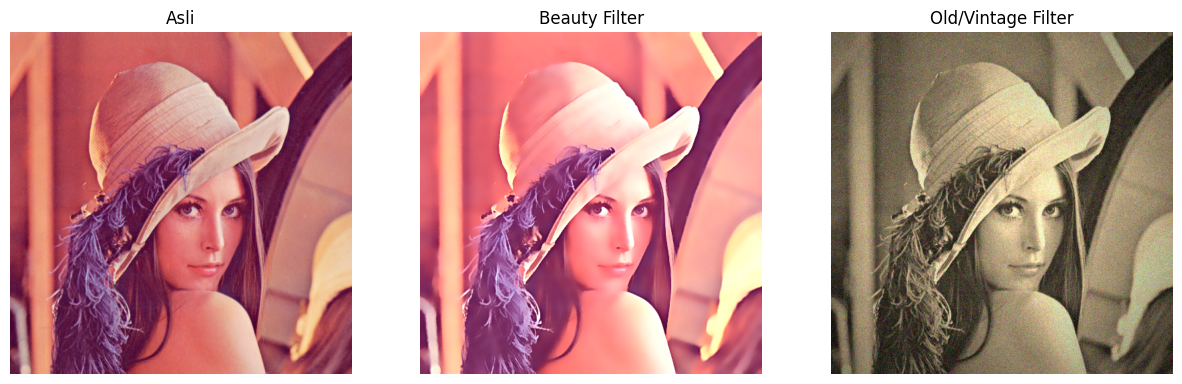

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi penampil citra
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load gambar asli
img = cv.imread('Lenna.png')

# ============================
# 1. Beauty Filter
# ============================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ============================
# 2. Old/Vintage Filter
# ============================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
np.random.seed(42)  # Menjaga konsistensi noise
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Visualisasi
show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

Percobaan5

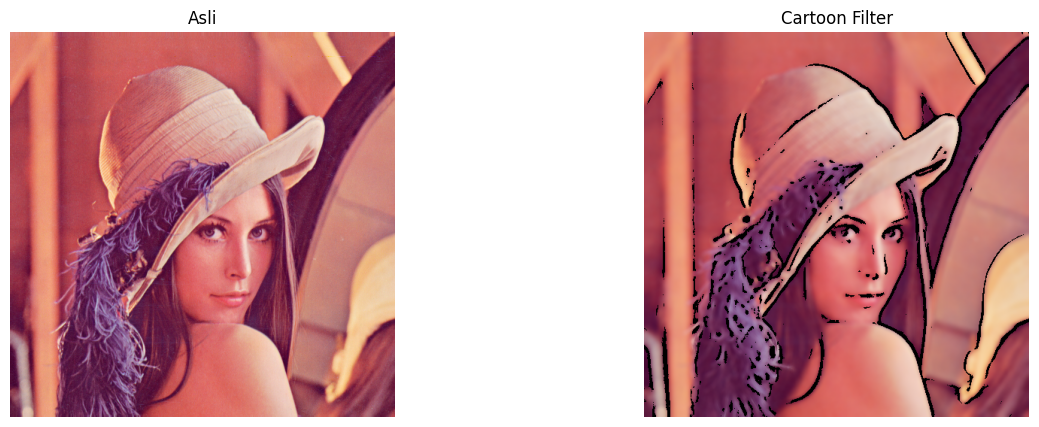

In [20]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Pastikan fungsi show_side_by_side sudah ada
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load gambar asli
img = cv.imread('Lenna.png')

# #Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

Percobaan6

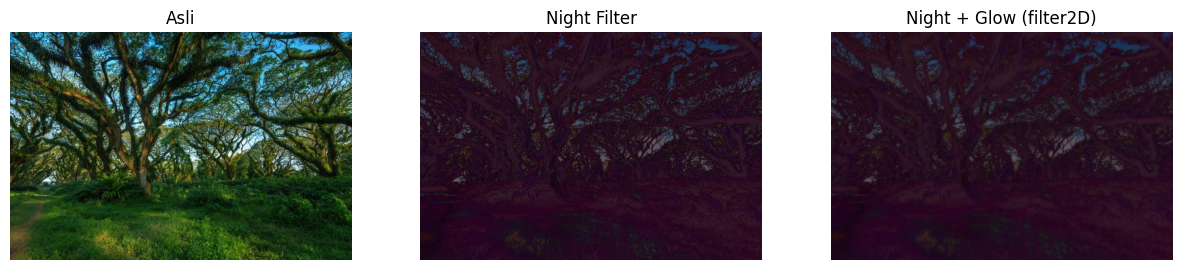

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Pastikan fungsi show_side_by_side sudah ada
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# #Night Filter
img = cv.imread("djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# Tampilkan hasil
show_side_by_side([img, night, night_glow],
                   ["Asli", "Night Filter", "Night + Glow (filter2D)"])

Percobaan7

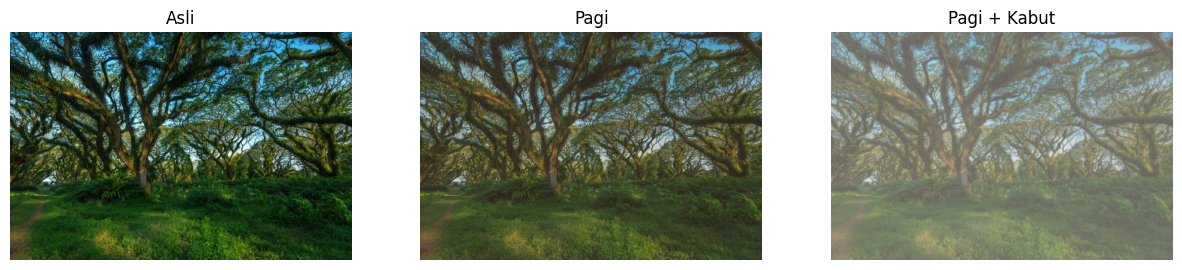

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Pastikan fungsi show_side_by_side sudah ada
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load gambar (menggunakan djawatan.jpg dari percobaan sebelumnya)
img = cv.imread("djawatan.jpg")

# #Filter Suasana pagi dan Kabut
# ==================================
# Step 1: Kurangi kontras & cerahkan
# ==================================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==================================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==================================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==================================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

# Tampilkan hasil
show_side_by_side([img, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])

Tugas

Soal1

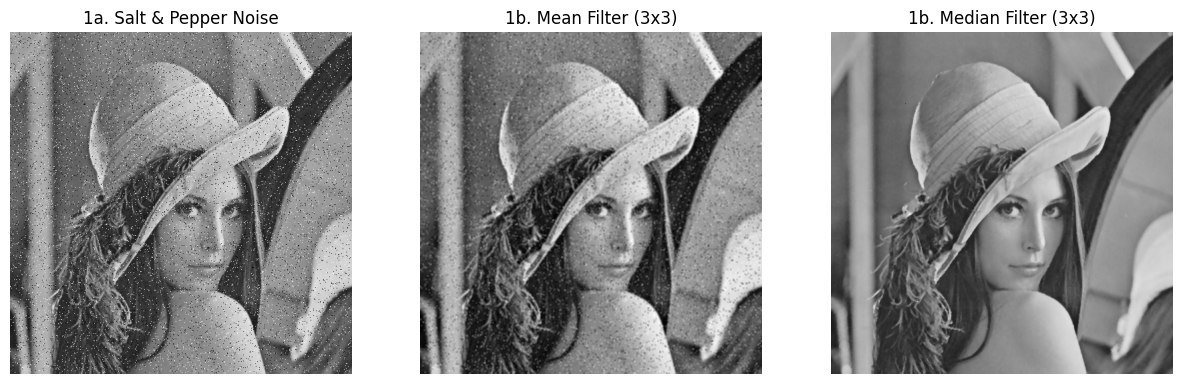

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Helper function untuk visualisasi
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load gambar Lenna
img = cv.imread('Lenna.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Tambahkan noise Salt & Pepper
noisy_img = img_gray.copy()
np.random.seed(42)
prob = 0.05  # 5% piksel rusak
num_salt = np.ceil(prob * img_gray.size * 0.5)
num_pepper = np.ceil(prob * img_gray.size * 0.5)

# Salt (Putih = 255)
coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_gray.shape]
noisy_img[tuple(coords)] = 255

# Pepper (Hitam = 0)
coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_gray.shape]
noisy_img[tuple(coords)] = 0

# b. Terapkan Mean Filter (3x3) & Median Filter (3x3)
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

# Tampilkan hasil
show_side_by_side([noisy_img, mean_filtered, median_filtered],
                   ["1a. Salt & Pepper Noise", "1b. Mean Filter (3x3)", "1b. Median Filter (3x3)"])

Soal2

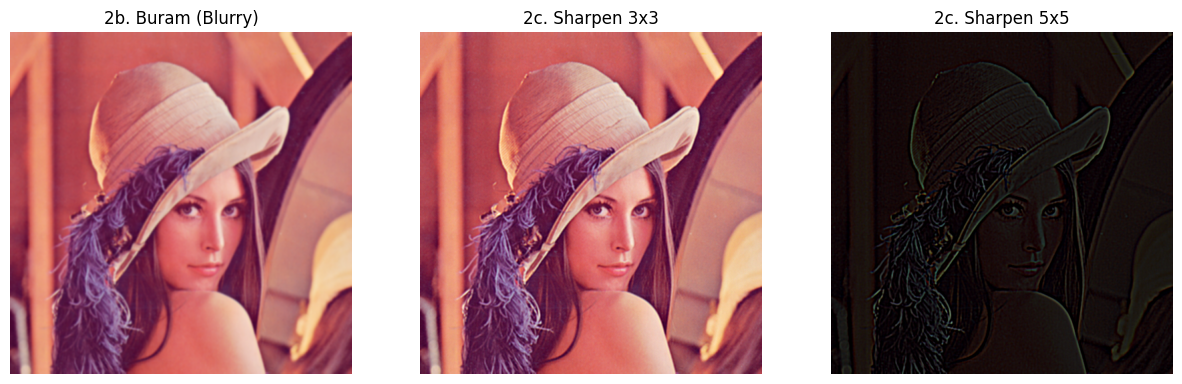

In [24]:
import cv2 as cv
import numpy as np

# Siapkan gambar sedikit buram (blurry)
blurry_img = cv.GaussianBlur(img, (5, 5), 0)

# a. Buat Kernel Sharpening 3x3 dan 5x5
kernel_3x3 = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])

kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, 25, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1]]) / 9.0

# b. Terapkan pada citra buram
sharpen_3x3 = cv.filter2D(blurry_img, -1, kernel_3x3)
sharpen_5x5 = cv.filter2D(blurry_img, -1, kernel_5x5)

# c. Tampilkan hasil
show_side_by_side([blurry_img, sharpen_3x3, sharpen_5x5],
                   ["2b. Buram (Blurry)", "2c. Sharpen 3x3", "2c. Sharpen 5x5"])

Soal3

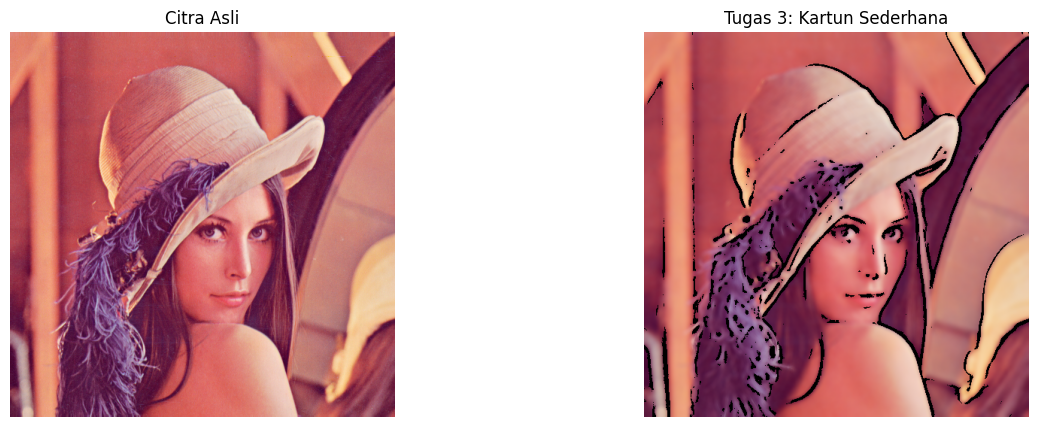

In [25]:
import cv2 as cv
import numpy as np

# a. Buat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna dengan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Convert edges ke 3 channel BGR agar sejajar dengan gambar warna
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Kombinasi menggunakan operasi perkalian piksel
    cartoon_img = (color.astype(np.float32) / 255.0) * (edges_bgr.astype(np.float32) / 255.0)
    cartoon_img = (cartoon_img * 255).astype(np.uint8)

    return cartoon_img

# b. Tampilkan citra asli dan hasil kartun bersebelahan
hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["Citra Asli", "Tugas 3: Kartun Sederhana"])